## Inteligență Artificială  Tema 1 - 2025: Sokoban

Responsabili:
- Andrei Olaru
- Cătălin Chiru
- Andrei Dugăeșescu
- Mihai Nan
- Vlad Matei Drăghici
- Alexandru Baciu
- Bogdan-Andrei Sprîncenatu

In [1]:
from sokoban import Map, save_images, create_gif
from search_methods.beam_search import beam_search
from search_methods.ida_star import ida
from search_methods.heuristics import minimum_matching
import pandas as pd
import time

# Importing all maps

In [2]:
maps = []
maps.append((Map.from_yaml('tests/easy_map1.yaml'), "easy_1"))
maps.append((Map.from_yaml('tests/easy_map2.yaml'), "easy_2"))
maps.append((Map.from_yaml('tests/medium_map1.yaml'), "medium_1"))
maps.append((Map.from_yaml('tests/medium_map2.yaml'), "medium_2"))
maps.append((Map.from_yaml('tests/hard_map1.yaml'), "hard_1"))
maps.append((Map.from_yaml('tests/hard_map2.yaml'), "hard_2"))
maps.append((Map.from_yaml('tests/large_map1.yaml'), "large_1"))
maps.append((Map.from_yaml('tests/large_map2.yaml'), "large_2"))
maps.append((Map.from_yaml('tests/super_hard_map1.yaml'), "super_hard"))

map_names = ["easy_1", "easy_2", "medium_1", "medium_2", "hard_1", "hard_2", "large_1", "large_2", "super_hard"]

# Solving with IDA*

In [3]:
ida_states = []
ida_time = []
ida_undo = []

for map, name in maps:
    start = time.time()
    res, explored, undo = ida(map, minimum_matching)
    end = time.time()
    if res is True:
        print("{0} was solved in {1} seconds & {2} states & {3} pull moves.".format(name, end-start, explored, undo))
        ida_states.append(explored)
        ida_time.append(end-start)
        ida_undo.append(undo)
    else: 
        print(name + " was not solved.")
        ida_states.append(0)
        ida_time.append(0)
        ida_undo.append(0)

easy_1 was solved in 0.0016367435455322266 seconds & 48 states & 1 pull moves.
easy_2 was solved in 0.0011730194091796875 seconds & 44 states & 1 pull moves.
medium_1 was solved in 0.0027604103088378906 seconds & 64 states & 2 pull moves.
medium_2 was solved in 0.06576919555664062 seconds & 1802 states & 4 pull moves.
hard_1 was solved in 0.010187387466430664 seconds & 165 states & 4 pull moves.
hard_2 was solved in 0.005751848220825195 seconds & 206 states & 2 pull moves.
large_1 was solved in 0.008744955062866211 seconds & 213 states & 7 pull moves.
large_2 was solved in 0.008333683013916016 seconds & 156 states & 7 pull moves.
super_hard was solved in 0.03296327590942383 seconds & 247 states & 13 pull moves.


# Solving with beam search 

In [4]:
beam_states = []
beam_time = []
beam_undo = []

for map, name in maps:
    start = time.time()
    res, explored, undo = beam_search(map, 90, minimum_matching)
    end = time.time()
    if res is True:
        print("{0} was solved in {1} seconds & {2} states & {3} pull moves.".format(name, end-start, explored, undo))
        beam_states.append(explored)
        beam_time.append(end-start)
        beam_undo.append(undo)
    else:
        print(name + " was not solved.")
        beam_states.append(0)
        beam_time.append(0)
        beam_undo.append(0)

easy_1 was solved in 0.02968597412109375 seconds & 1559 states & 1 pull moves.
easy_2 was solved in 0.012221097946166992 seconds & 740 states & 0 pull moves.
medium_1 was solved in 0.027671337127685547 seconds & 1577 states & 3 pull moves.
medium_2 was solved in 0.11513733863830566 seconds & 4571 states & 5 pull moves.
hard_1 was solved in 0.2154216766357422 seconds & 5488 states & 4 pull moves.
hard_2 was solved in 0.13033246994018555 seconds & 6033 states & 2 pull moves.
large_1 was solved in 0.1901857852935791 seconds & 6281 states & 3 pull moves.
large_2 was solved in 0.24623632431030273 seconds & 7841 states & 5 pull moves.
super_hard was solved in 1.364152431488037 seconds & 12142 states & 14 pull moves.


# Generated states comparison

<Axes: xlabel='Number of explored states per map'>

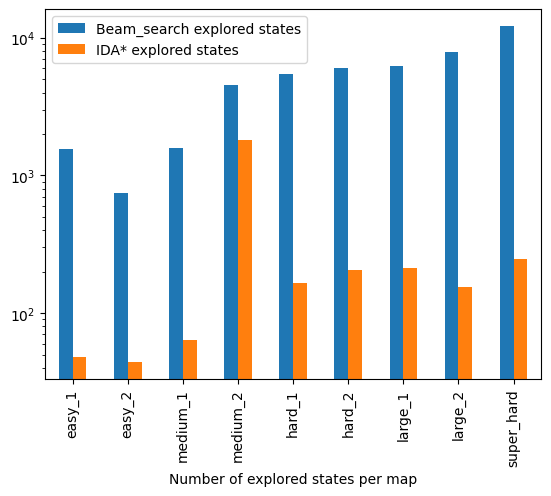

In [5]:
sf = pd.DataFrame({
    'Number of explored states per map': map_names,
    'Beam_search explored states': beam_states,
    'IDA* explored states': ida_states
})

sf.plot(x='Number of explored states per map', y=['Beam_search explored states', 'IDA* explored states'], kind="bar", logy=True)

# Time comparison

<Axes: xlabel='Time to solve per map'>

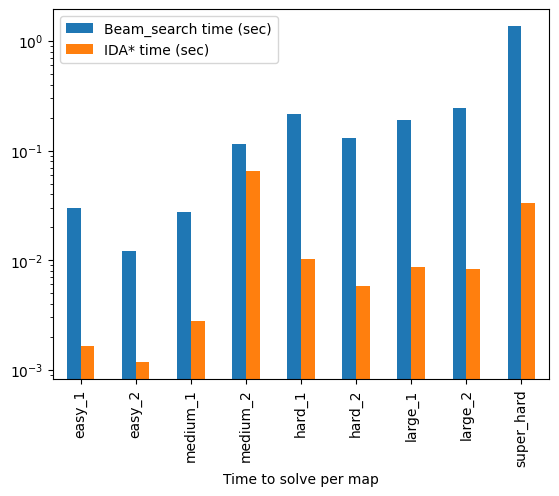

In [6]:
tf = pd.DataFrame({
    'Time to solve per map': map_names,
    'Beam_search time (sec)': beam_time,
    'IDA* time (sec)': ida_time
})

tf.plot(x='Time to solve per map', y=['Beam_search time (sec)', 'IDA* time (sec)'], kind="bar", logy=True)

# Cost comparison

<Axes: xlabel='Algorithm cost per map'>

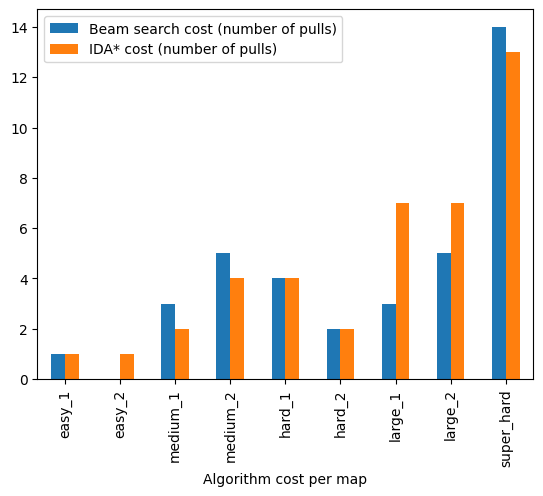

In [7]:
cf = pd.DataFrame({
    'Algorithm cost per map': map_names,
    'Beam search cost (number of pulls)': beam_undo,
    'IDA* cost (number of pulls)': ida_undo
})

cf.plot(x='Algorithm cost per map', y=['Beam search cost (number of pulls)', 'IDA* cost (number of pulls)'], kind='bar')